# GBDT vs NN

Thin orchestration notebook for the default `NN` vs `GBDT` analysis.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_dir = notebook_dir.parent
repo_root = project_dir.parent

sys.path.insert(0, str(project_dir / "src"))
sys.path.insert(0, str(repo_root / "tabarena" / "tabarena"))

In [ ]:
from mfa import load_config, run_analysis

config = load_config(project_dir / "configs" / "config_0.yaml")
result = run_analysis(
    config,
    # datasets=[
    #     "Bank_Customer_Churn",
    #     "MIC",
    #     "Marketing_Campaign",
    #     "bank-marketing",
    #     "blood-transfusion-service-center",
    #     "credit_card_clients_default",
    #     "diabetes",
    #     "hiva_agnostic",
    #     "in_vehicle_coupon_recommendation",
    #     "maternal_health_risk",
    # ],
)
result.analysis_table.head()

12:45:18 INFO mfa.pipeline: Starting analysis: comparisons=nn_vs_tree; scope=10 selected dataset(s); unit=dataset; method_variant=tuned; n_jobs=32
12:45:18 INFO mfa.pipeline: Stage 1/5 raw results: cache hit (3705 rows, 10 dataset(s))
12:45:18 WARNING mfa.groups: Group `tfm` contains config_types absent from data: TABICLV2, TABICL_GPU, TABPFN-V2.6
12:45:18 INFO mfa.pipeline: Stage 2/5 meta-features: trace enabled, bypassing metafeature caches for live diagnostics
12:45:18 INFO mfa.pipeline: Stage 2/5 meta-features: building for 10 selected dataset(s)
12:45:18 INFO mfa.metafeatures: Meta-features: preparing 10 dataset(s) with feature_sets=basic (n_jobs=32)
12:45:18 INFO mfa.metafeatures: Meta-features: trace enabled with n_jobs=32; per-split logs may interleave. Use n_jobs=1 for ordered traces.
12:45:18 INFO mfa.metafeatures: Meta-features: submitting 195 split(s) across 10 dataset(s) to 32 worker(s)
Meta-features:   0%|          | 0/195 [00:00<?, ?split/s]12:45:19 INFO mfa.metafeatures

,dataset,comparison_name,group_a_name,group_b_name,group_a_label,group_b_label,expected_direction,n_splits,n,d,...,best_a_error,best_a_norm_error,best_b_error,best_b_norm_error,delta_raw,delta_raw_std,delta_raw_sem,delta_norm,delta_norm_std,delta_norm_sem
0,Bank_Customer_Churn,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,6666.666667,10.0,...,0.130036,0.540574,0.129614,0.488169,0.000422,0.001437,0.000479,0.052405,0.183040,0.061013
1,MIC,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,30,1132.666667,111.0,...,0.431601,0.169445,0.445650,0.550351,-0.014049,0.012953,0.002365,-0.380906,0.311860,0.056938
2,Marketing_Campaign,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,30,1493.333333,25.0,...,0.091055,0.751909,0.091988,0.834722,-0.000933,0.007363,0.001344,-0.082813,0.363082,0.066289
3,bank-marketing,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,30140.666667,13.0,...,0.236199,0.547259,0.234576,0.153585,0.001623,0.001171,0.000390,0.393674,0.289982,0.096661
4,blood-transfusion-service-center,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,30,498.666667,4.0,...,0.249095,0.580808,0.254064,0.737625,-0.004970,0.014333,0.002617,-0.156818,0.421827,0.077015


In [3]:
import pandas as pd

# -- Inspect what the result object contains --
print(f"config_hash:        {result.config_hash}")
print(f"comparison_name:    {result.comparison_name}")
print(f"analysis_table:     {result.analysis_table.shape}")
print(f"gap_table:          {result.gap_table.shape}")
print(f"metafeature_table:  {result.metafeature_table.shape}")
print(f"correlation_results: {len(result.correlation_results)} features tested")
print(
    f"correction_result:  {result.correction_result.method if result.correction_result else None}"
)
print(f"multivariate_result: {result.multivariate_result}")

config_hash:        6fb7c3822a3db796
comparison_name:    nn_vs_tree
analysis_table:     (10, 24)
gap_table:          (195, 17)
metafeature_table:  (195, 9)
correlation_results: 6 features tested
correction_result:  bh
multivariate_result: None


## Correlation summary table

In [4]:
import numpy as np

# Build a comprehensive table from correlation + correction results
corr_df = pd.DataFrame([r.__dict__ for r in result.correlation_results])

if result.correction_result is not None:
    corr_df["p_value_adj"] = result.correction_result.adjusted_p_values
    corr_df["rejected"] = result.correction_result.rejected

# Add a significance star column for quick scanning
p_col = "p_value_adj" if "p_value_adj" in corr_df.columns else "p_value"
corr_df["sig"] = np.where(
    corr_df[p_col] < 0.001,
    "***",
    np.where(corr_df[p_col] < 0.01, "**", np.where(corr_df[p_col] < 0.05, "*", "")),
)

display_cols = [
    "predictor",
    "statistic",
    "ci_lower",
    "ci_upper",
    "p_value",
    *(["p_value_adj", "rejected"] if "p_value_adj" in corr_df.columns else []),
    "sig",
    "n_observations",
    "direction_confirmed",
]

corr_df[display_cols].sort_values("p_value")

,predictor,statistic,ci_lower,ci_upper,p_value,p_value_adj,rejected,sig,n_observations,direction_confirmed
1,d,-0.478788,-0.803922,0.192053,0.161523,0.822692,False,,10,None
4,cat_fraction,-0.288365,-0.761072,0.466916,0.419090,0.822692,False,,10,None
3,n_over_d,0.284848,-0.575066,0.887517,0.425038,0.822692,False,,10,None
5,missing_fraction,-0.216250,-0.748331,0.417734,0.548461,0.822692,False,,10,None
0,n,-0.066667,-0.831169,0.692308,0.854813,0.854813,False,,10,None
2,log_n,-0.066667,-0.831169,0.692308,0.854813,0.854813,False,,10,None


## Correlation scatter plots

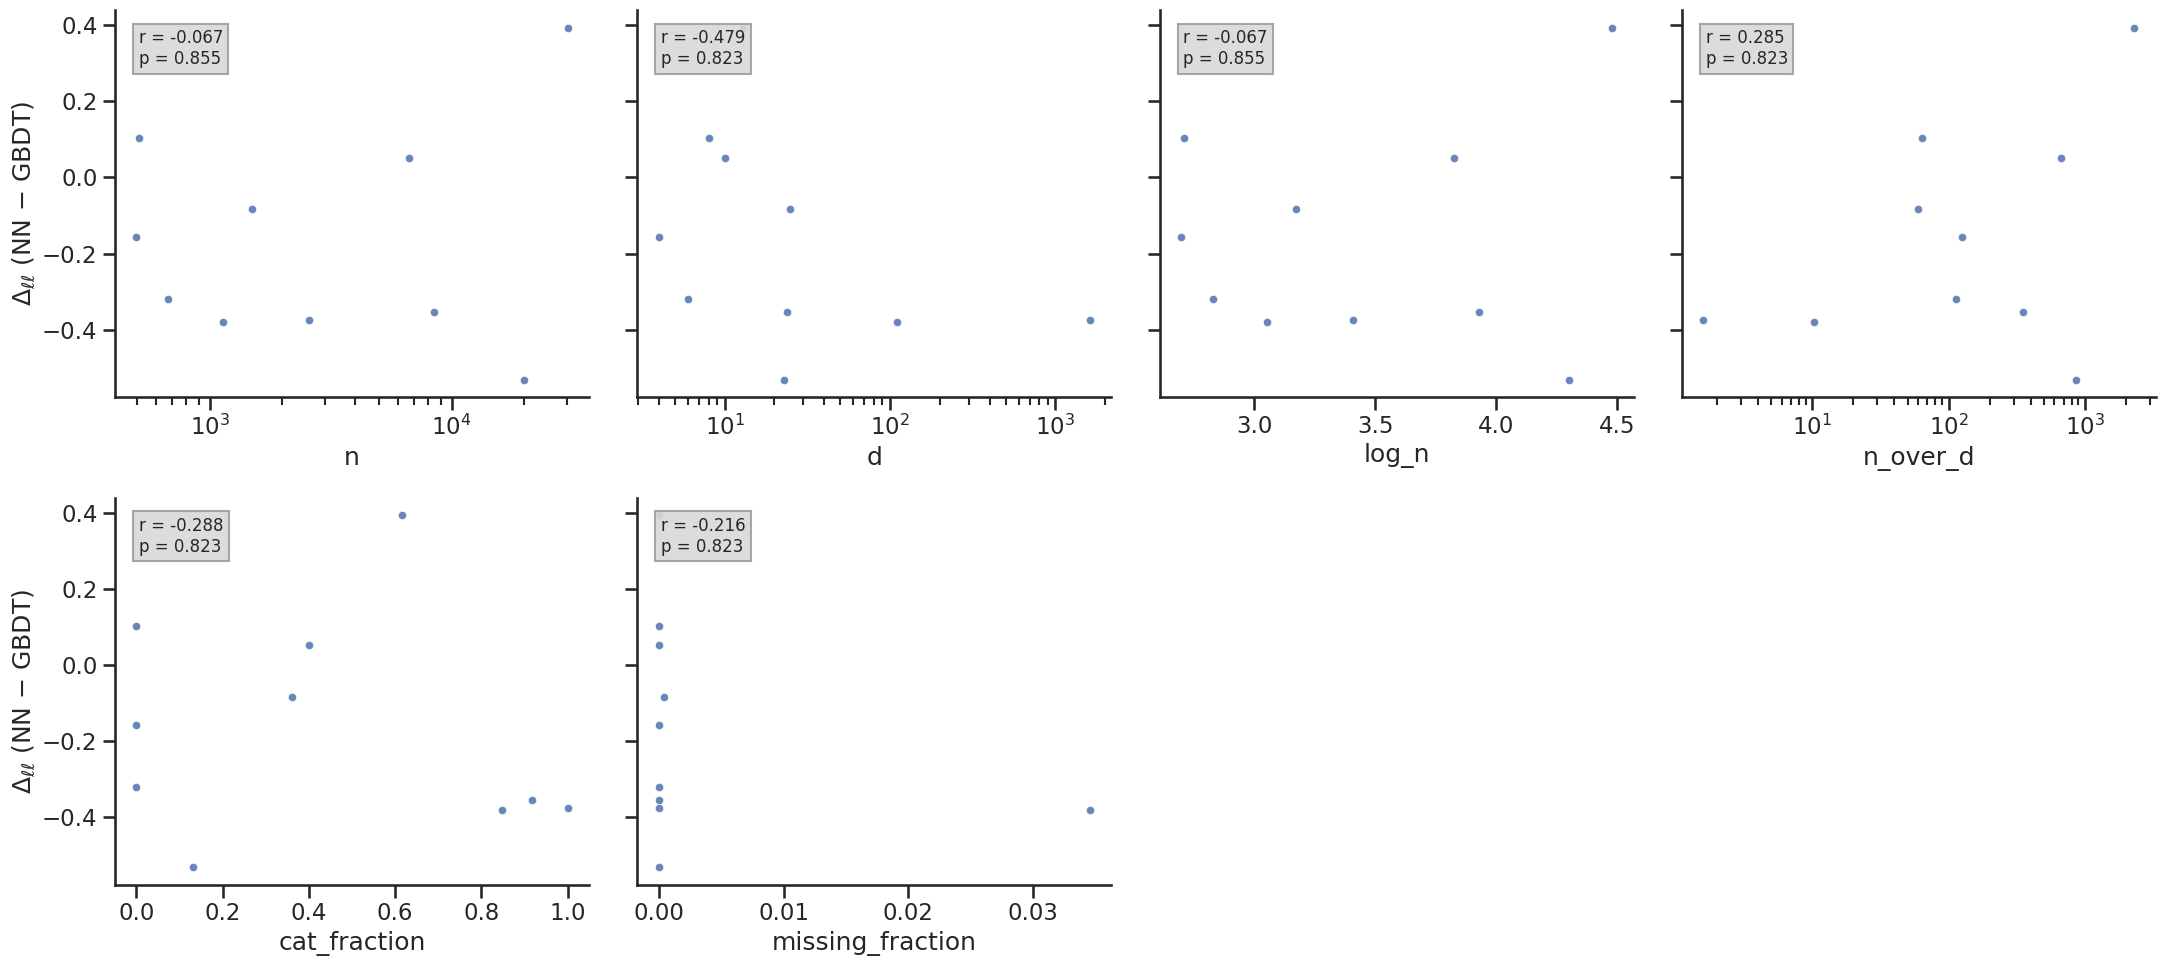

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="talk")

analysis = result.analysis_table.copy()
predictors = corr_df["predictor"].tolist()
n_preds = len(predictors)
ncols = min(4, n_preds)
nrows = int(np.ceil(n_preds / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), sharey=True, squeeze=False
)

for idx, predictor in enumerate(predictors):
    ax = axes[idx // ncols][idx % ncols]
    plot_df = analysis[[predictor, "delta_norm"]].dropna()

    # Use log scale for features that are strictly positive and span orders of magnitude
    use_log = (plot_df[predictor] > 0).all() and (
        plot_df[predictor].max() / plot_df[predictor].min() > 10
    )

    sns.scatterplot(data=plot_df, x=predictor, y="delta_norm", s=35, alpha=0.85, ax=ax)
    if use_log:
        ax.set_xscale("log")

    ax.set_xlabel(predictor)
    if idx % ncols == 0:
        ax.set_ylabel(r"$\Delta_{\ell\ell}$ (NN − GBDT)")
    else:
        ax.set_ylabel("")

    # Annotate with correlation and adjusted p-value
    row = corr_df.loc[corr_df["predictor"] == predictor].iloc[0]
    p_display = row.get("p_value_adj", row["p_value"])
    ax.text(
        0.05,
        0.95,
        f"r = {row['statistic']:.3f}\np = {p_display:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox={"facecolor": "#d9d9d9", "edgecolor": "#9e9e9e", "alpha": 0.9},
    )

# Hide unused subplots
for idx in range(n_preds, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

sns.despine()
fig.tight_layout()
plt.show()